In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

In [3]:
path_parquet_1='/content/drive/MyDrive/Maestria Ingenieria y analitica de datos/semestre 4/proyecto de grado/fuentes de datos/base_finales/base_filtrada/'

In [4]:
base_final=pd.read_parquet(path_parquet_1)

In [5]:
# ==============================================================================
# PASO 1: CARGA DE DATOS Y CONSTRUCCIÓN DE ÍNDICES SINTÉTICOS
# ==============================================================================
import time
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# 1.1 Columnas requeridas del dataset
selected_columns = [
    # Demográficas e individuales
    "estu_genero",
    "estu_fechanacimiento",
    "estu_horassemanatrabaja",
    "estu_dedicacioninternet",
    "estu_dedicacionlecturadiaria",
    # Socioeconómicas y familiares
    "fami_estratovivienda",
    "fami_educacionmadre",
    "estu_inse_individual",
    "estu_nse_establecimiento",
    "fami_personashogar",
    "fami_cuartoshogar",
    "fami_numlibros",
    "fami_trabajolabormadre",
    "fami_trabajolaborpadre",
    # Bienes para índice de bienes
    "fami_tieneautomovil",
    "fami_tienecomputador",
    "fami_tieneconsolavideojuegos",
    "fami_tienehornomicroogas",
    "fami_tieneinternet",
    "fami_tienelavadora",
    "fami_tienemotocicleta",
    "fami_tieneserviciotv",
    # Alimentos para índice de consumo alimentario
    "fami_comecarnepescadohuevo",
    "fami_comecerealfrutoslegumbre",
    "fami_comelechederivados",
    # Institucionales y territoriales
    "cole_naturaleza",
    "cole_area_ubicacion",
    "cole_calendario",
    "cole_jornada",
    "cole_caracter",
    "cole_cod_mcpio_ubicacion",
    "estu_cod_reside_depto",
    "estu_cod_reside_mcpio",
    "periodo",
    "punt_global",
]

df_estudio = pd.read_parquet(path_parquet_1, columns=selected_columns)

# 1.2 Ingeniería de características inicial (Edad)
df_estudio["ano_examen"] = (
    df_estudio["periodo"].astype(str).str[:4].astype(int)
)
df_estudio["estu_fechanacimiento"] = pd.to_datetime(
    df_estudio["estu_fechanacimiento"], format="%d/%m/%Y", errors="coerce"
)
df_estudio["estu_edad"] = (
    df_estudio["ano_examen"] - df_estudio["estu_fechanacimiento"].dt.year
)
df_estudio = df_estudio[
    (df_estudio["estu_edad"] >= 10) & (df_estudio["estu_edad"] <= 80)
].copy()
df_estudio.dropna(subset=["punt_global"], inplace=True)
df_estudio.drop(columns=["estu_fechanacimiento", "ano_examen"], inplace=True)

# 1.3 Construcción del Índice de Bienes (0 a 8)
cols_bienes = [
    "fami_tieneautomovil",
    "fami_tienecomputador",
    "fami_tieneconsolavideojuegos",
    "fami_tienehornomicroogas",
    "fami_tieneinternet",
    "fami_tienelavadora",
    "fami_tienemotocicleta",
    "fami_tieneserviciotv",
]

# Conversión a binario: 1 si es 'Si', 0 en caso contrario
for col in cols_bienes:
    df_estudio[col + "_bin"] = (df_estudio[col].astype(str).str.upper() == "SI").astype(int)

df_estudio["indice_bienes"] = df_estudio[[c + "_bin" for c in cols_bienes]].sum(axis=1)
df_estudio.drop(columns=cols_bienes + [c + "_bin" for c in cols_bienes], inplace=True)

# 1.4 Construcción del Índice de Consumo Alimentario (0 a 9)
# Escala de frecuencia según catálogo DataIcfes
map_consumo = {
    "Nunca o rara vez comemos eso": 0,
    "1 o 2 veces por semana": 1,
    "3 a 5 veces por semana": 2,
    "Todos o casi todos los días": 3,
}

cols_consumo = [
    "fami_comecarnepescadohuevo",
    "fami_comecerealfrutoslegumbre",
    "fami_comelechederivados",
]

for col in cols_consumo:
    df_estudio[col + "_num"] = df_estudio[col].map(map_consumo).fillna(0).astype(int)

df_estudio["indice_consumo"] = df_estudio[[c + "_num" for c in cols_consumo]].sum(axis=1)
df_estudio.drop(columns=cols_consumo + [c + "_num" for c in cols_consumo], inplace=True)

In [6]:
# ==============================================================================
# PASO 2: CONFIGURACIÓN DEL PREPROCESADOR (ORDINAL, NOMINAL Y NUMÉRICO)
# ==============================================================================
# Jerarquías ordinales
orden_educacion = [
    "Ninguno",
    "Primaria incompleta",
    "Primaria completa",
    "Secundaria (Bachillerato) incompleta",
    "Secundaria (Bachillerato) completa",
    "Técnica o tecnológica incompleta",
    "Técnica o tecnológica completa",
    "Educación profesional incompleta",
    "Educación profesional completa",
    "Postgrado",
]
orden_horas_trabajo = [
    "0",
    "Menos de 10 horas",
    "Entre 11 y 20 horas",
    "Entre 21 y 30 horas",
    "Más de 30 horas",
]
orden_internet = [
    "No Navega Internet",
    "30 minutos o menos",
    "Entre 30 y 60 minutos",
    "Entre 1 y 3 horas",
    "Más de 3 horas",
]
orden_lectura = [
    "No leo por entretenimiento",
    "30 minutos o menos",
    "Entre 30 y 60 minutos",
    "Entre 1 y 2 horas",
    "Más de 2 horas",
]
orden_estrato = [
    "Sin Estrato",
    "Estrato 1",
    "Estrato 2",
    "Estrato 3",
    "Estrato 4",
    "Estrato 5",
    "Estrato 6",
]
orden_personas_hogar = ["1 a 2", "3 a 4", "5 a 6", "7 a 8", "9 o más"]
orden_cuartos = ["Uno", "Dos", "Tres", "Cuatro", "Cinco", "Seis o más"]
orden_libros = [
    "0 A 10 LIBROS",
    "11 A 25 LIBROS",
    "26 A 100 LIBROS",
    "MÁS DE 100 LIBROS",
]

ordinal_cols = [
    "fami_educacionmadre",
    "estu_horassemanatrabaja",
    "estu_dedicacioninternet",
    "estu_dedicacionlecturadiaria",
    "fami_estratovivienda",
    "fami_personashogar",
    "fami_cuartoshogar",
    "fami_numlibros",
]

ordinal_categories = [
    orden_educacion,
    orden_horas_trabajo,
    orden_internet,
    orden_lectura,
    orden_estrato,
    orden_personas_hogar,
    orden_cuartos,
    orden_libros,
]

nominal_cols = [
    "estu_genero",
    "fami_trabajolabormadre",
    "fami_trabajolaborpadre",
    "cole_naturaleza",
    "cole_area_ubicacion",
    "cole_calendario",
    "cole_jornada",
    "cole_caracter",
    "cole_cod_mcpio_ubicacion",
    "estu_cod_reside_depto",
    "estu_cod_reside_mcpio",
]

# Se incorporan los nuevos índices sintéticos en numéricas
numeric_cols = [
    "estu_edad",
    "estu_inse_individual",
    "estu_nse_establecimiento",
    "indice_bienes",
    "indice_consumo",
]

X = df_estudio.drop(columns=["punt_global", "periodo"])
y = df_estudio["punt_global"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

ordinal_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "ordinal",
            OrdinalEncoder(
                categories=ordinal_categories,
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
        ),
    ]
)

nominal_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

numeric_pipeline = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median"))]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("ord", ordinal_pipeline, ordinal_cols),
        ("nom", nominal_pipeline, nominal_cols),
    ]
)

In [7]:
# 2.1 Calcular Edad y filtrar inconsistencias (con validación de existencia)
if 'estu_fechanacimiento' in df_estudio.columns:
    df_estudio['ano_examen'] = df_estudio['periodo'].astype(str).str[:4].astype(int)
    df_estudio['estu_fechanacimiento'] = pd.to_datetime(
        df_estudio['estu_fechanacimiento'],
        format='%d/%m/%Y',
        errors='coerce'
    )
    df_estudio['estu_edad'] = df_estudio['ano_examen'] - df_estudio['estu_fechanacimiento'].dt.year
    df_estudio.drop(columns=['estu_fechanacimiento', 'ano_examen'], inplace=True)

# Filtro de coherencia demográfica
df_estudio = df_estudio[(df_estudio['estu_edad'] >= 10) & (df_estudio['estu_edad'] <= 80)].copy()
df_estudio.dropna(subset=['punt_global'], inplace=True)

Entrenando el modelo Random Forest con nuevos índices...
Entrenamiento completado en 9.43 minutos.

--- MÉTRICAS (TRAIN) ---
R²:   0.3811
RMSE: 39.35
MAE:  31.88

--- MÉTRICAS (TEST) ---
R²:   0.3639
RMSE: 39.93
MAE:  32.31

Delta R² (Train - Test): 0.0173


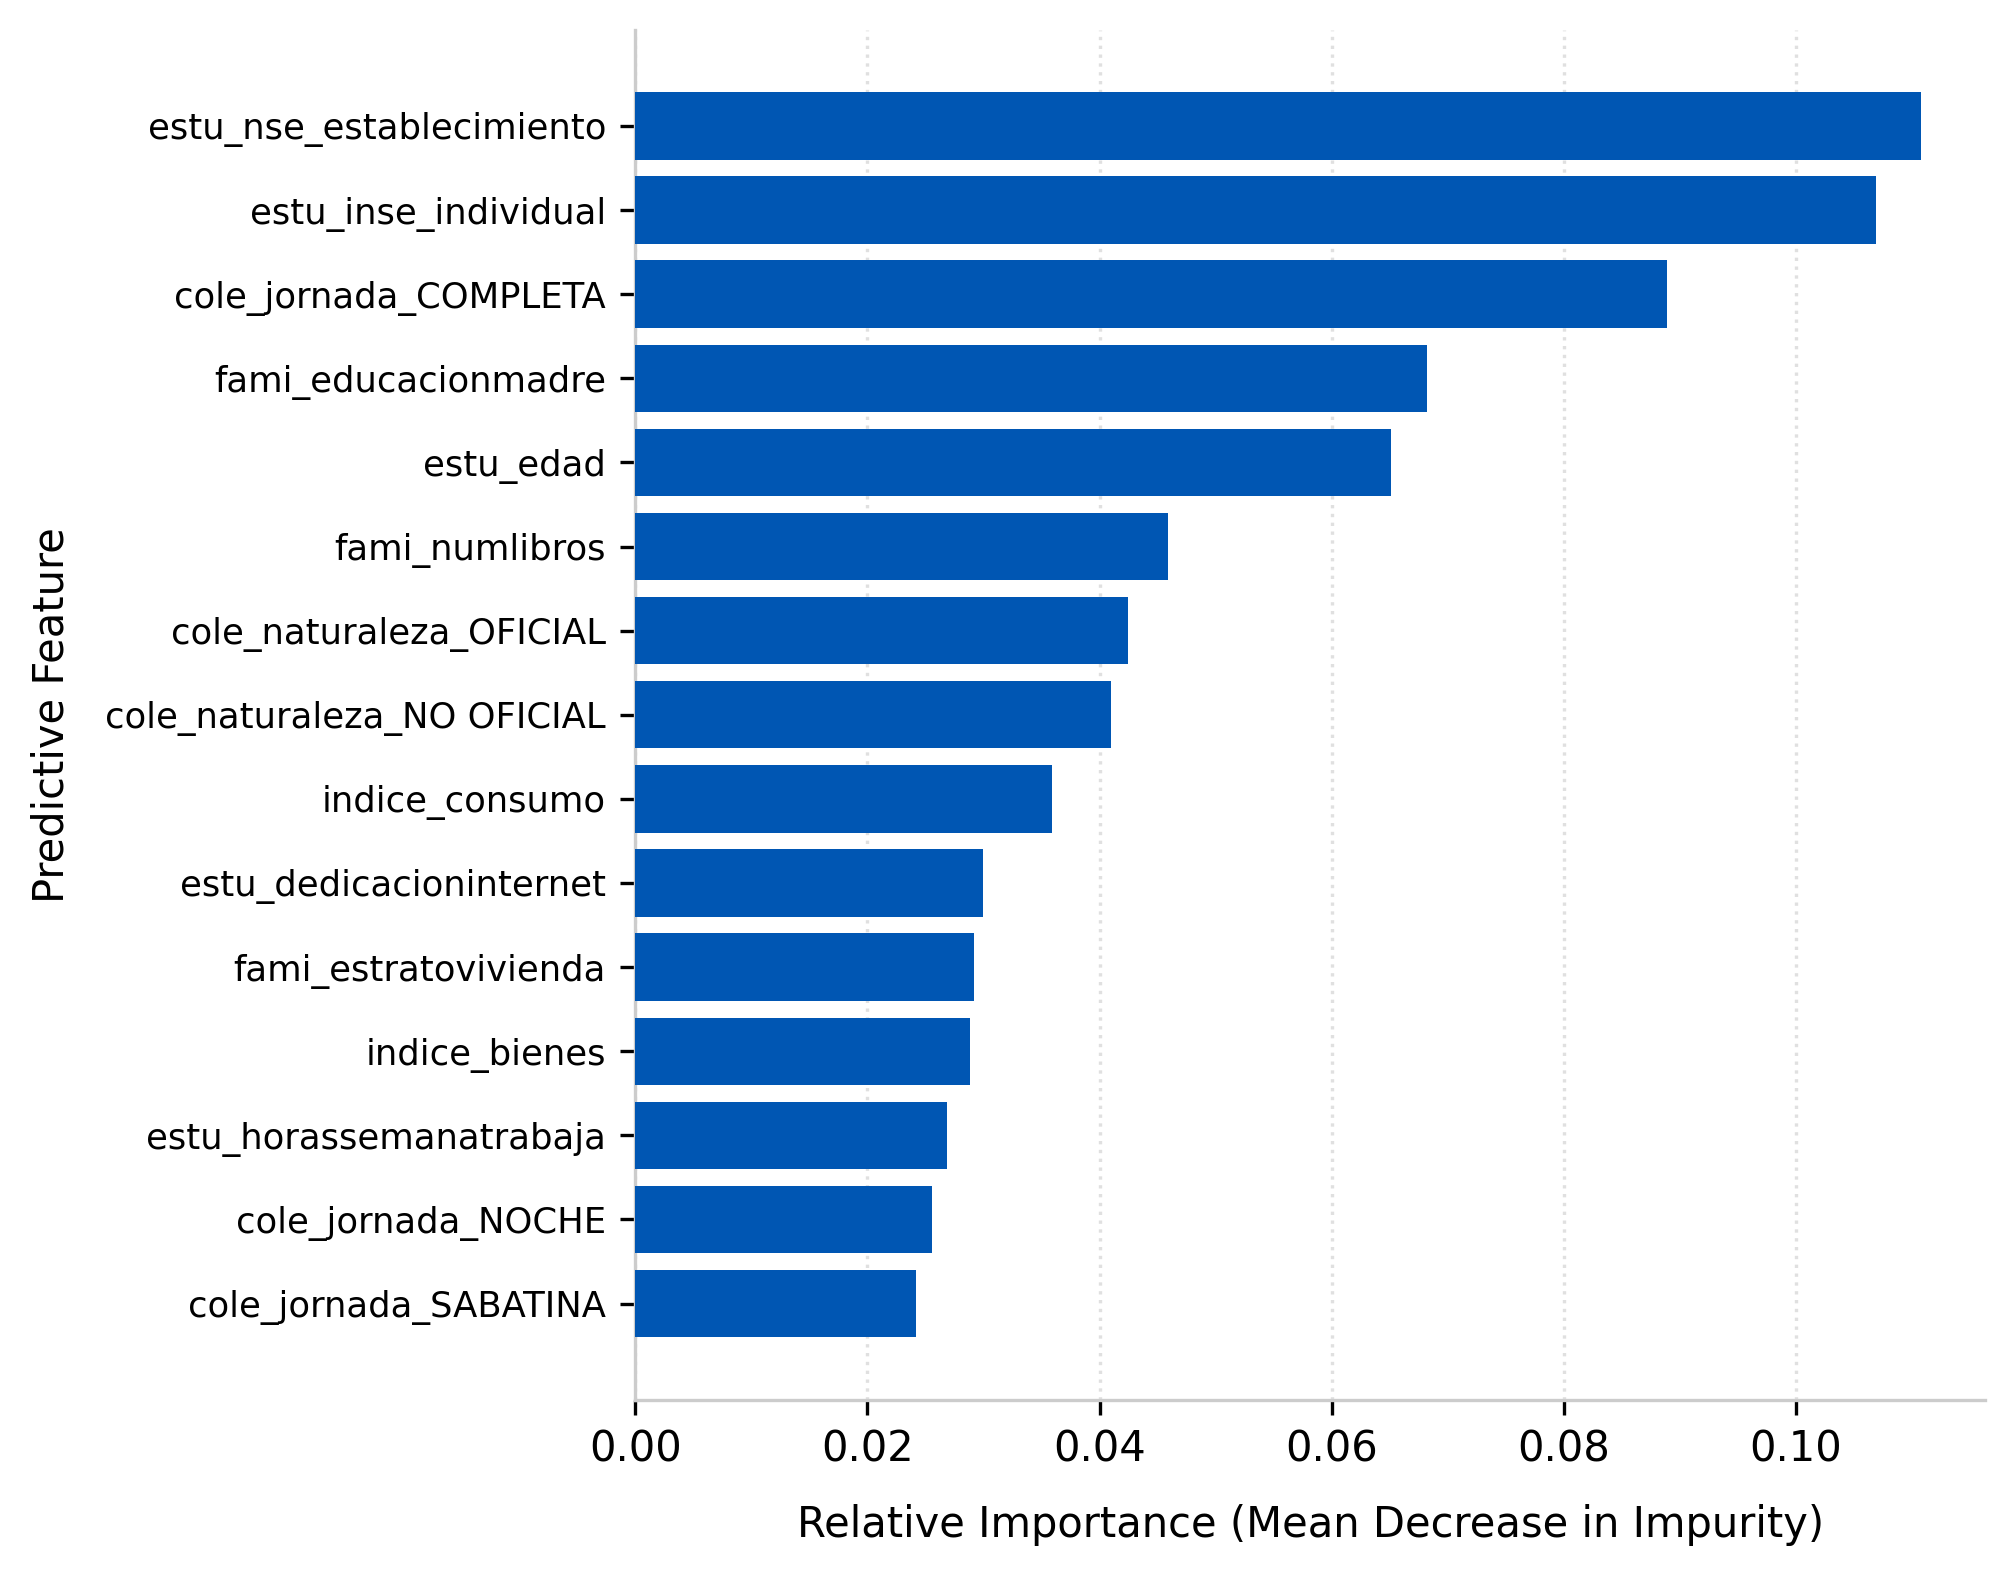

In [8]:
# ==============================================================================
# PASO 3: ENTRENAMIENTO, EVALUACIÓN Y FEATURE IMPORTANCE
# ==============================================================================
# 1. Configuración del estimador y ensamble del Pipeline
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42,
)

rf_pipeline = Pipeline(
    steps=[("preprocessor", preprocessor), ("regressor", rf_model)]
)

# 2. Entrenamiento
print("Entrenando el modelo Random Forest con nuevos índices...")
start_time = time.time()
rf_pipeline.fit(X_train, y_train)
print(
    f"Entrenamiento completado en {(time.time() - start_time) / 60:.2f} minutos."
)

# 3. Predicciones sobre Train y Test
y_pred_train = rf_pipeline.predict(X_train)
y_pred_test = rf_pipeline.predict(X_test)

# 4. Cálculo de métricas
r2_train = r2_score(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
mae_train = mean_absolute_error(y_train, y_pred_train)

r2_test = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)

print("\n--- MÉTRICAS (TRAIN) ---")
print(f"R²:   {r2_train:.4f}")
print(f"RMSE: {rmse_train:.2f}")
print(f"MAE:  {mae_train:.2f}")

print("\n--- MÉTRICAS (TEST) ---")
print(f"R²:   {r2_test:.4f}")
print(f"RMSE: {rmse_test:.2f}")
print(f"MAE:  {mae_test:.2f}")

print(f"\nDelta R² (Train - Test): {r2_train - r2_test:.4f}")

# 5. Importancia de características (MDI)
ohe_names = (
    rf_pipeline.named_steps["preprocessor"]
    .named_transformers_["nom"]
    .named_steps["onehot"]
    .get_feature_names_out(nominal_cols)
)
all_features = numeric_cols + ordinal_cols + list(ohe_names)
importances = rf_pipeline.named_steps["regressor"].feature_importances_

df_imp = (
    pd.DataFrame({"Feature": all_features, "Importance": importances})
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

top_15 = df_imp.head(15)

# 6. Generación de gráfica editorial
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=300)
y_pos = np.arange(len(top_15))
ax.barh(
    y_pos,
    top_15["Importance"],
    align="center",
    color="#0056b3",
    edgecolor="none",
    zorder=3,
)
ax.set_yticks(y_pos)
ax.set_yticklabels(top_15["Feature"], fontsize=8.5)
ax.invert_yaxis()
ax.set_xlabel("Relative Importance (Mean Decrease in Impurity)", labelpad=8)
ax.set_ylabel("Predictive Feature", labelpad=8)
ax.xaxis.grid(True, linestyle=":", alpha=0.6, color="#CCCCCC", zorder=0)
ax.yaxis.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#CCCCCC")
ax.spines["bottom"].set_color("#CCCCCC")
plt.subplots_adjust(left=0.45, right=0.95, top=0.95, bottom=0.12)
plt.savefig("rf_importance_indices.png", dpi=300, bbox_inches="tight")
plt.show()